In [70]:
# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# To Display All the columns

pd.set_option('display.max_columns', None)


In [105]:
# Loading CSV Dataset

df = pd.read_csv('/content/train.csv')

# Shape of our Dataet

df.shape

(1460, 81)

#NULL CHECK


In [72]:
# Finding Columns with Null Values and whats the percentage of Null value present in that column

Null_columns = [features for features in df.columns if df[features].isnull().sum()>0]

for columns in Null_columns:
  print(f"{columns} has {round(df[columns].isnull().mean()* 100,2)} % of Null Values")

LotFrontage has 17.74 % of Null Values
Alley has 93.77 % of Null Values
MasVnrType has 59.73 % of Null Values
MasVnrArea has 0.55 % of Null Values
BsmtQual has 2.53 % of Null Values
BsmtCond has 2.53 % of Null Values
BsmtExposure has 2.6 % of Null Values
BsmtFinType1 has 2.53 % of Null Values
BsmtFinType2 has 2.6 % of Null Values
Electrical has 0.07 % of Null Values
FireplaceQu has 47.26 % of Null Values
GarageType has 5.55 % of Null Values
GarageYrBlt has 5.55 % of Null Values
GarageFinish has 5.55 % of Null Values
GarageQual has 5.55 % of Null Values
GarageCond has 5.55 % of Null Values
PoolQC has 99.52 % of Null Values
Fence has 80.75 % of Null Values
MiscFeature has 96.3 % of Null Values


# How Nulls are affecting

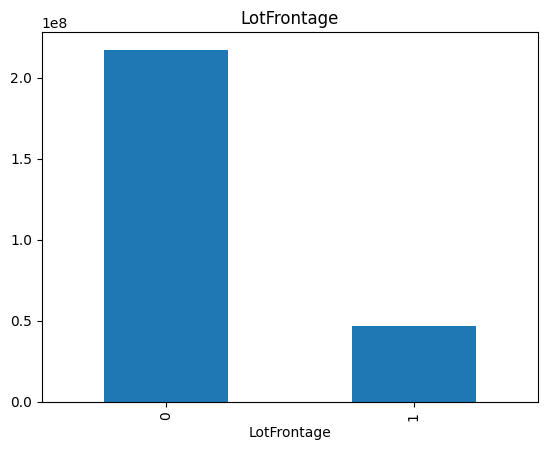

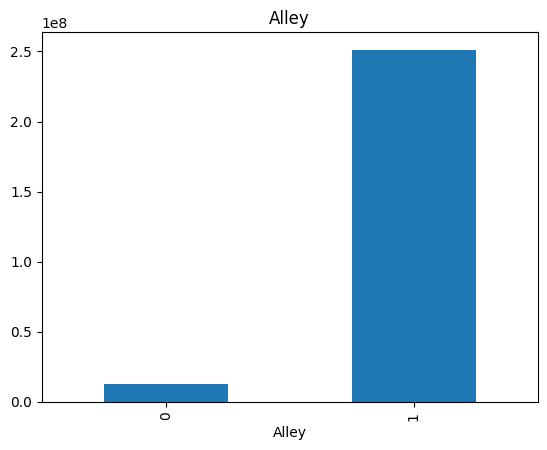

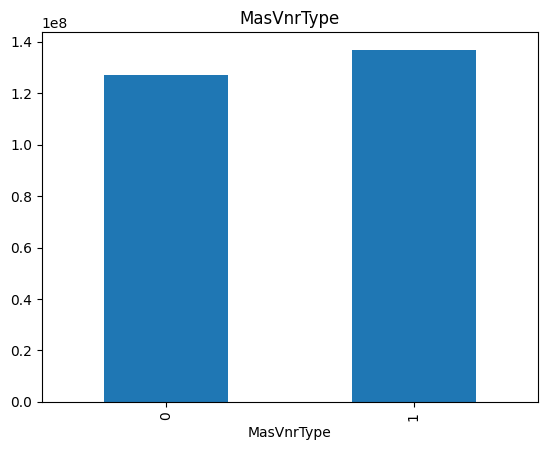

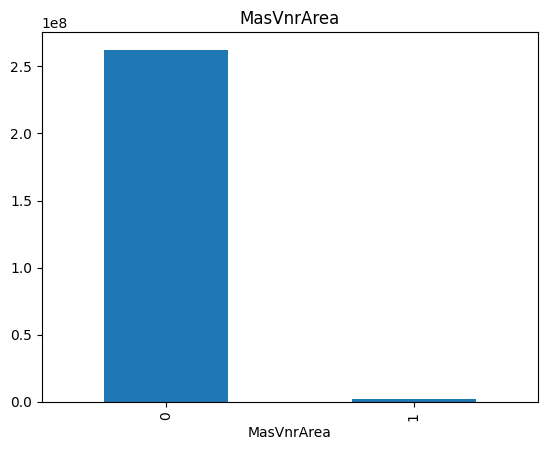

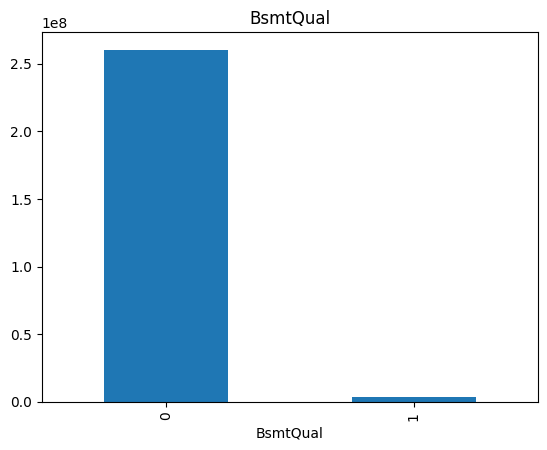

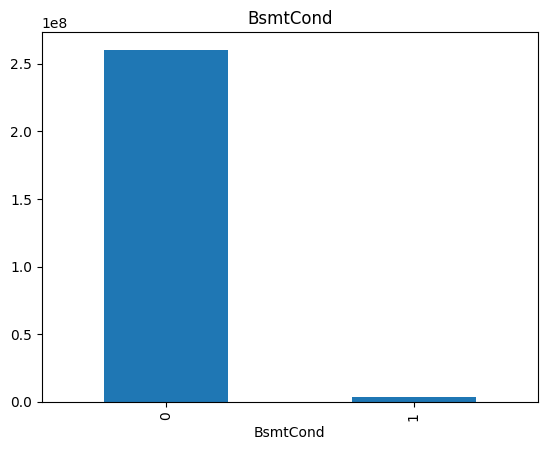

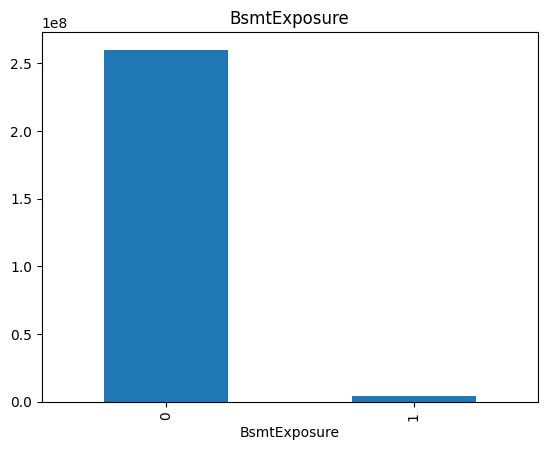

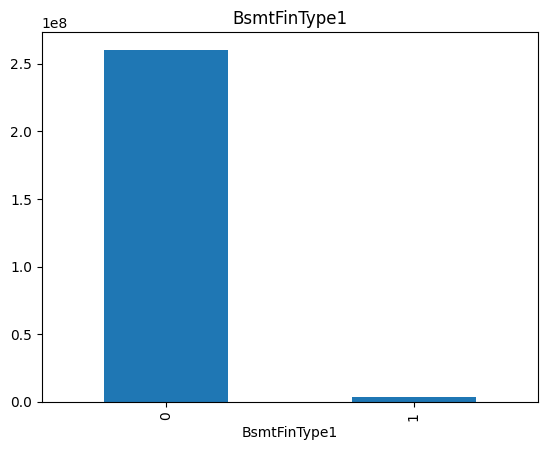

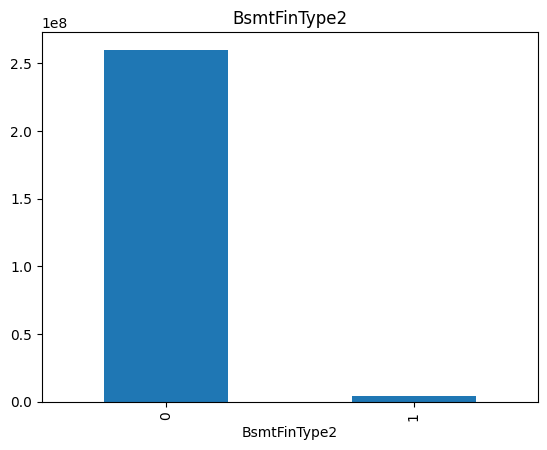

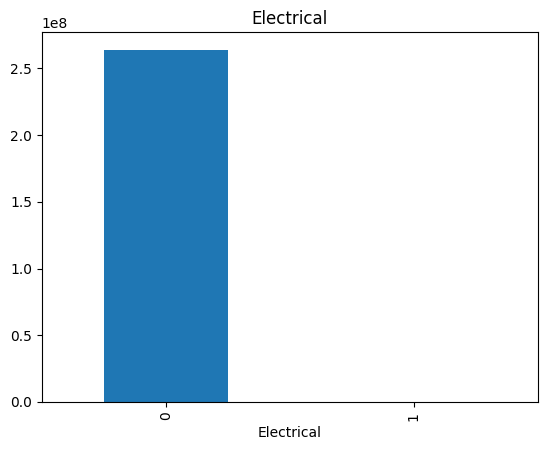

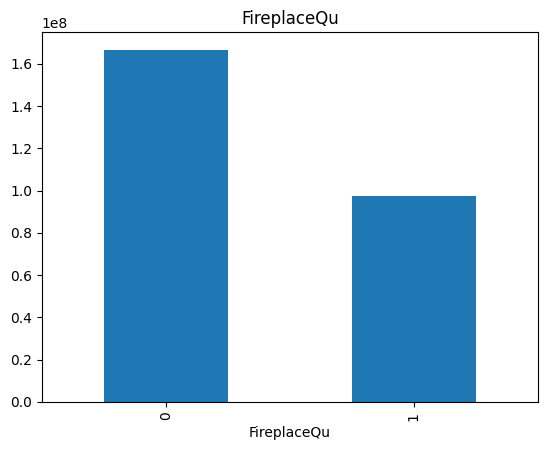

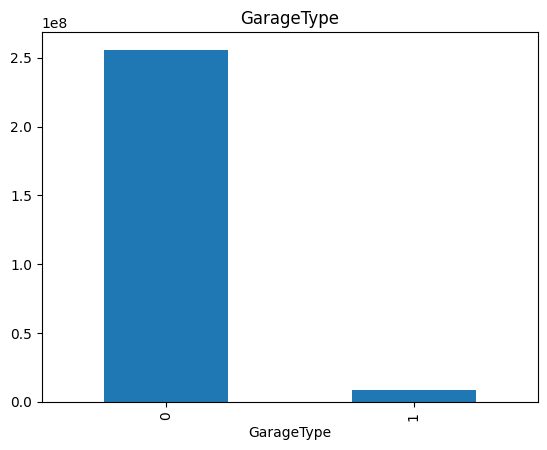

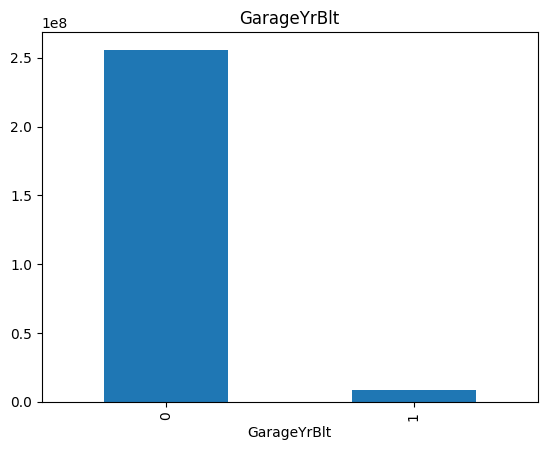

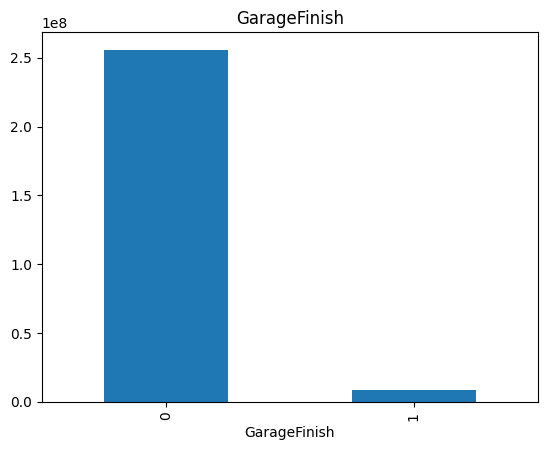

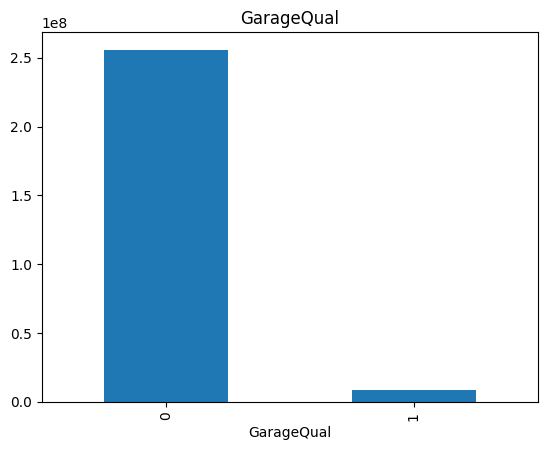

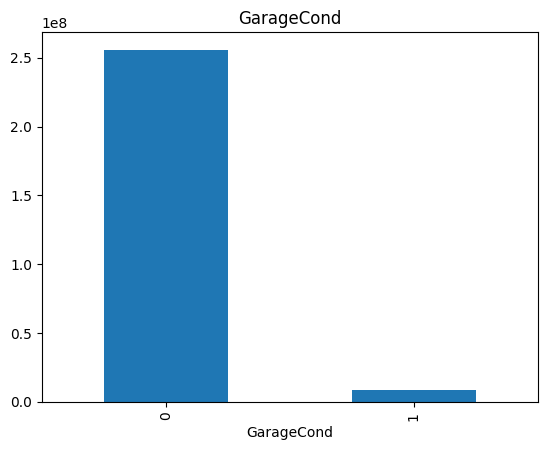

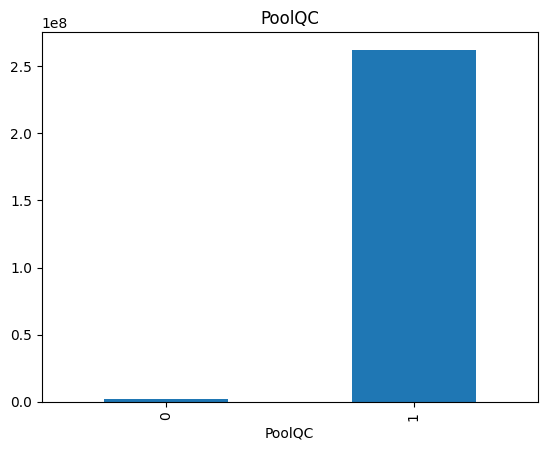

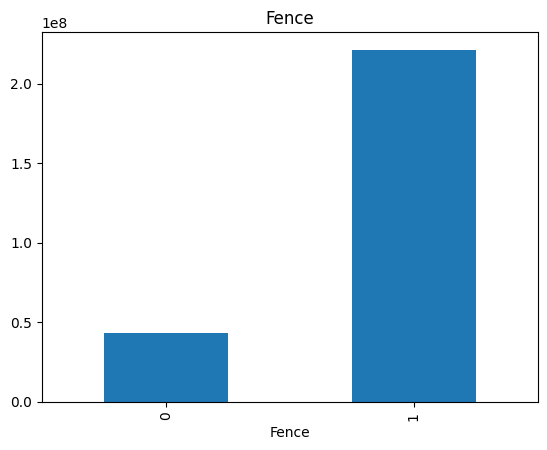

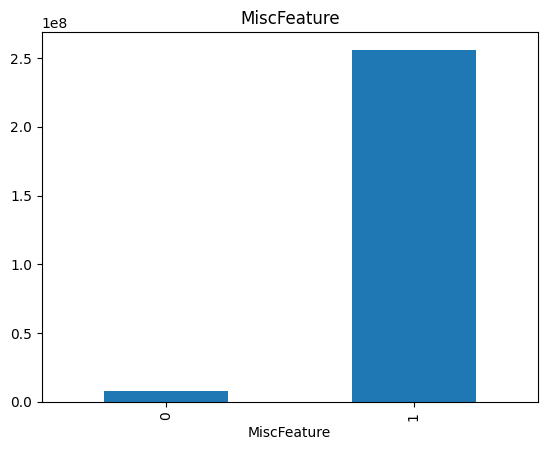

In [73]:
data  = df.copy(deep=True) # Now since we are going to apply some changes to the dataset so its better to make a copy

for features in Null_columns:

  #Here we are assigning Null values as 1 and all other values as 0 in all columns with null values. It helps to compare
  data[features] = np.where(data[features].isnull(),1,0)

  #Group the data by Null columns and show the Saleprice of groups as aggregation then plot it
  data.groupby(features)['SalePrice'].sum().plot.bar()
  plt.title(features)
  plt.show()


#Categorizing Columns

In [84]:
years = [features for features in df if 'Year' in features or 'Yr' in features]
Cat_var = [features for features in df.columns if df[features].dtypes == 'O']
Num_var = [features for features in df.columns if features not in Cat_var and features not in years]
Num_var_dis = [features for features in Num_var if len(df[features].unique()) < 25]
Num_var_cont = [features for features in Num_var if len(df[features].unique()) > 25]


print(f"There are {len(Cat_var)} Categorical Variables")
print(f"There are {len(Num_var)} Numerical Variables")
print(f"There are {len(Num_var_dis)} Discrete Numerical Variables")
print(f"There are {len(Num_var_cont)} Continuous Numerical Variables")

There are 43 Categorical Variables
There are 34 Numerical Variables
There are 17 Discrete Numerical Variables
There are 17 Continuous Numerical Variables


## Sale Prices over time

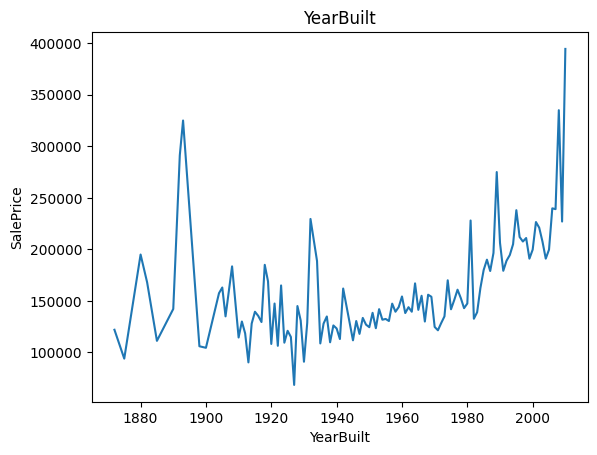

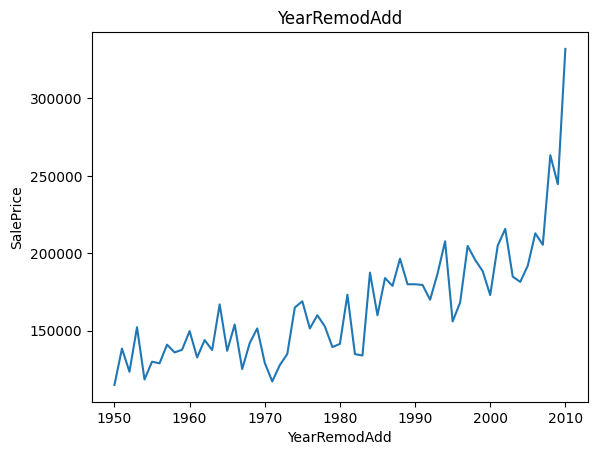

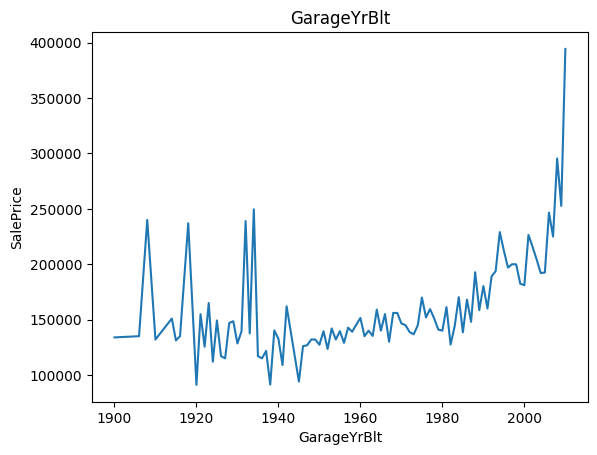

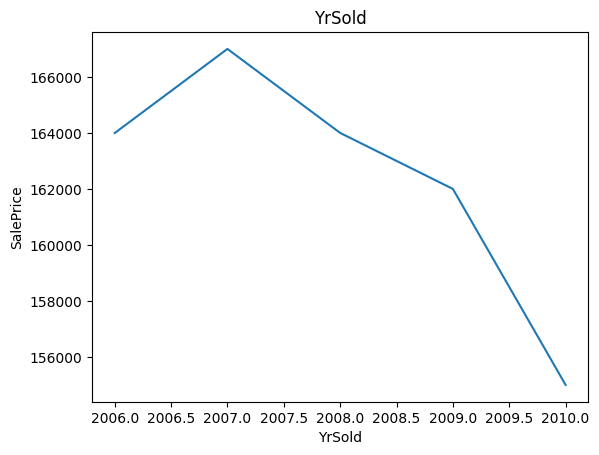

In [85]:
for features in years:
  df.groupby(features)['SalePrice'].median().plot()
  plt.xlabel(features)
  plt.ylabel('SalePrice')
  plt.title(features)
  plt.show()

# Sales Price over Discrete Numerical columns

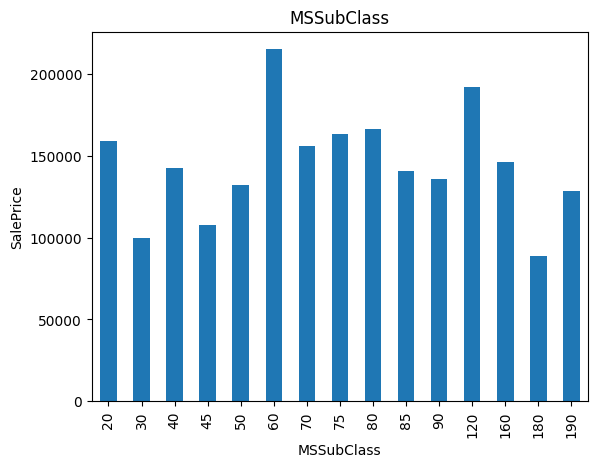

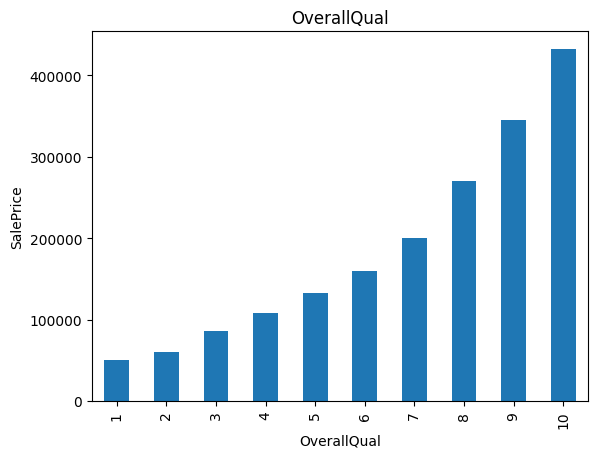

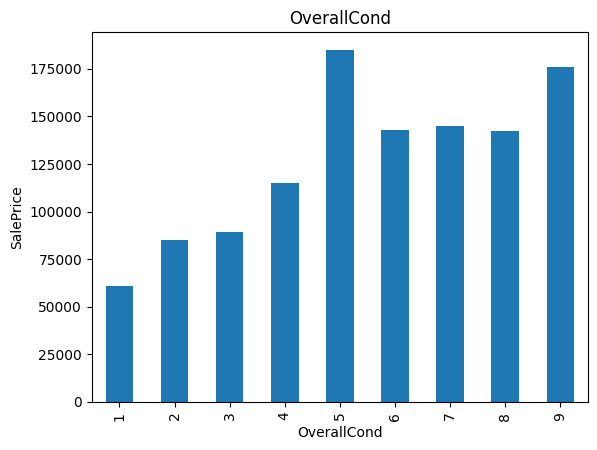

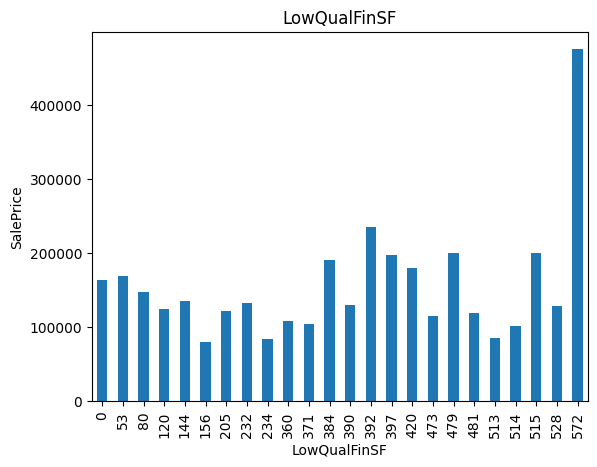

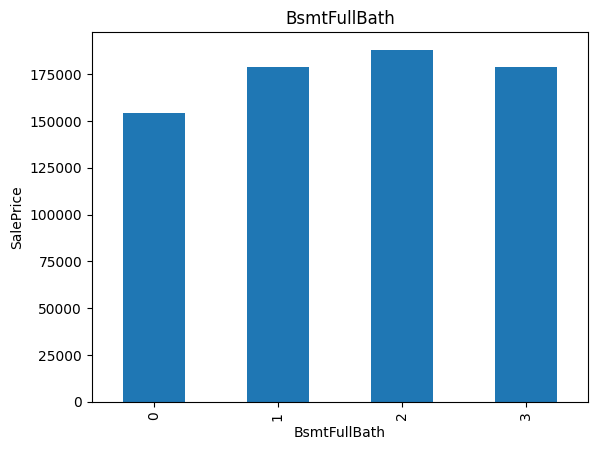

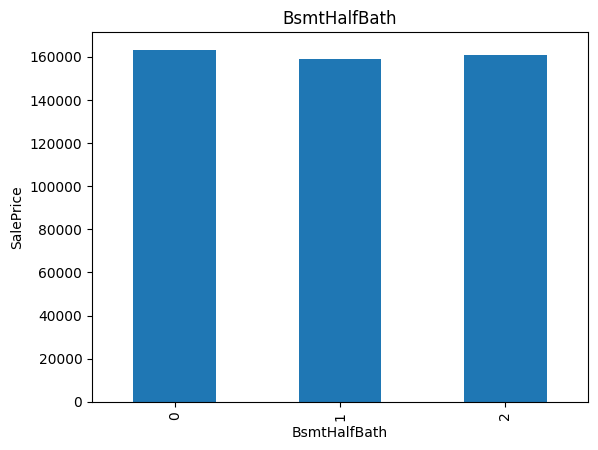

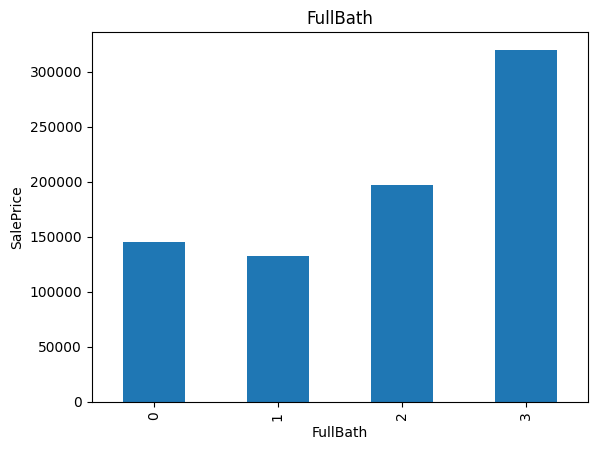

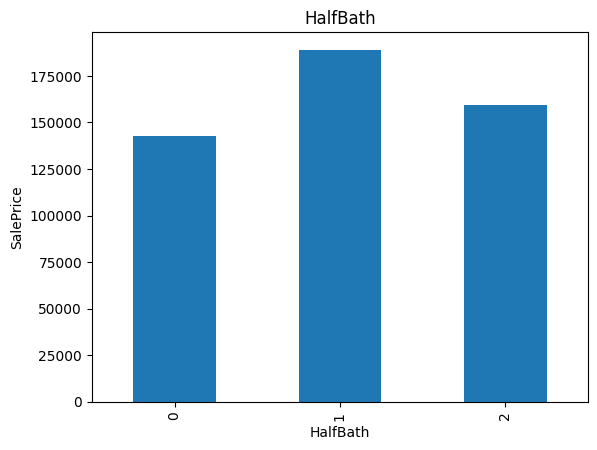

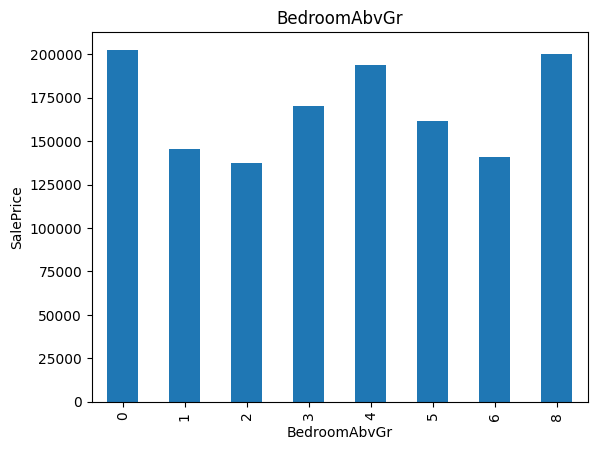

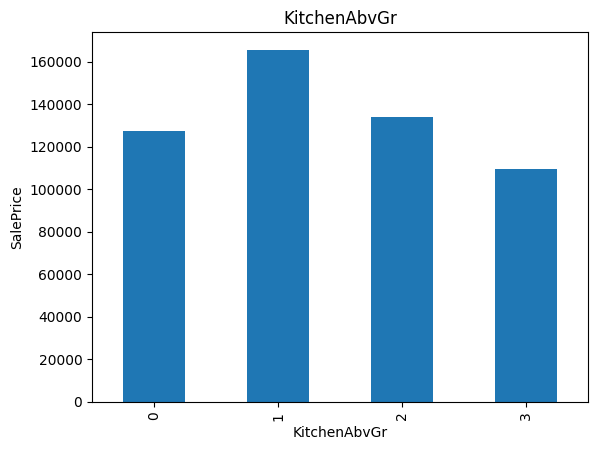

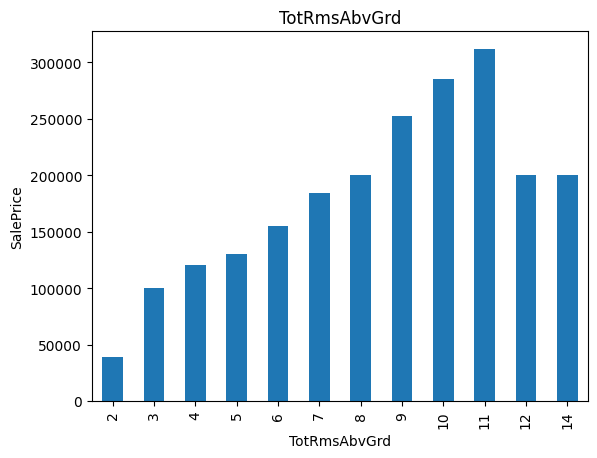

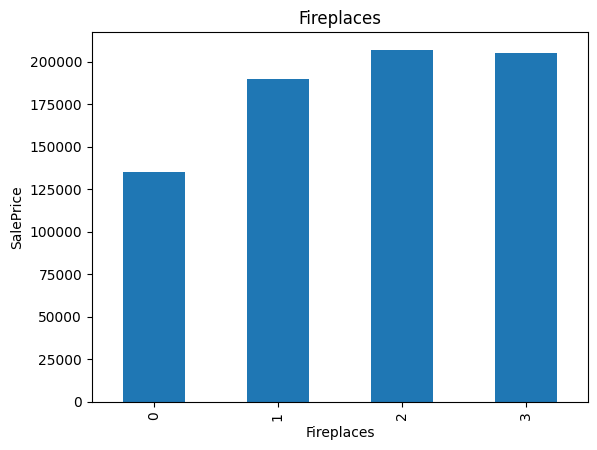

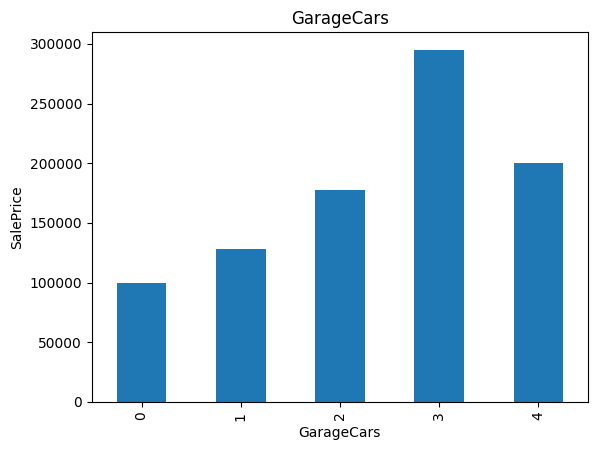

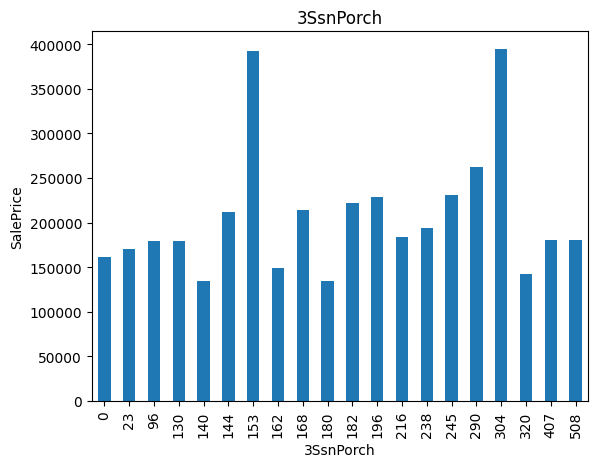

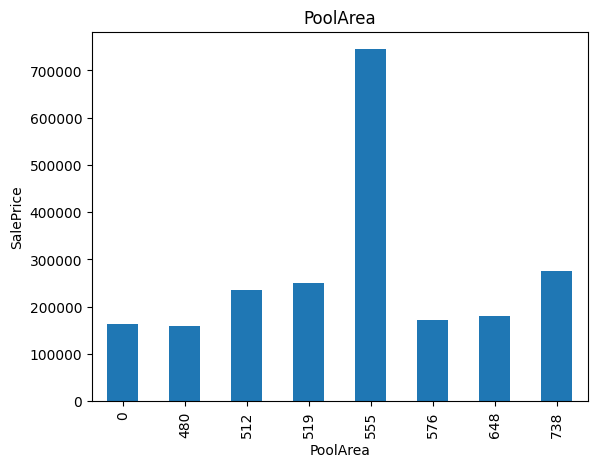

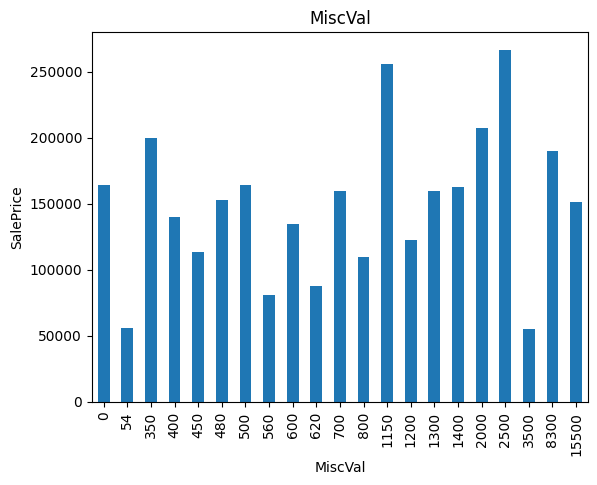

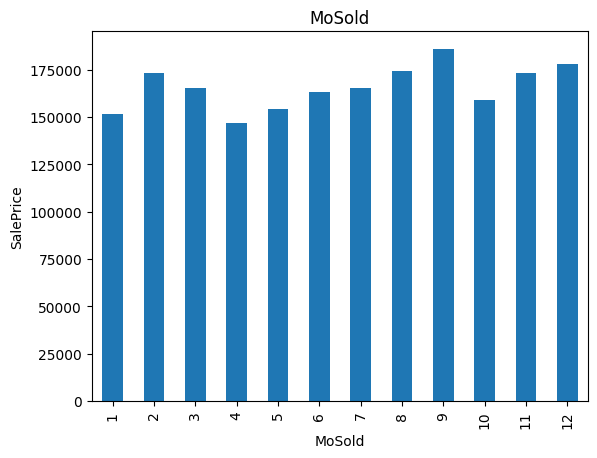

In [86]:
for features in Num_var_dis:
  df.groupby(features)['SalePrice'].median().plot.bar()
  plt.xlabel(features)
  plt.ylabel('SalePrice')
  plt.title(features)
  plt.show()


# Sales Price over continous value features


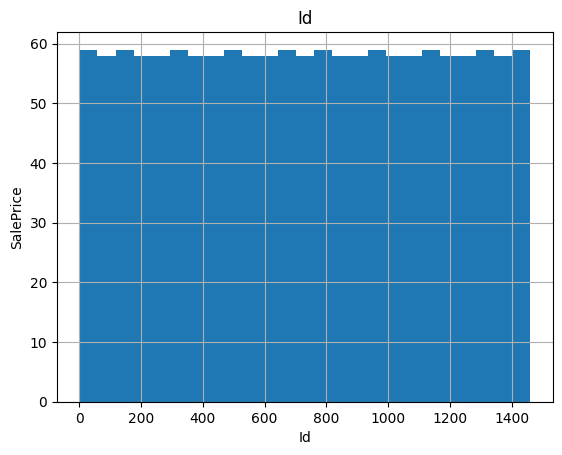

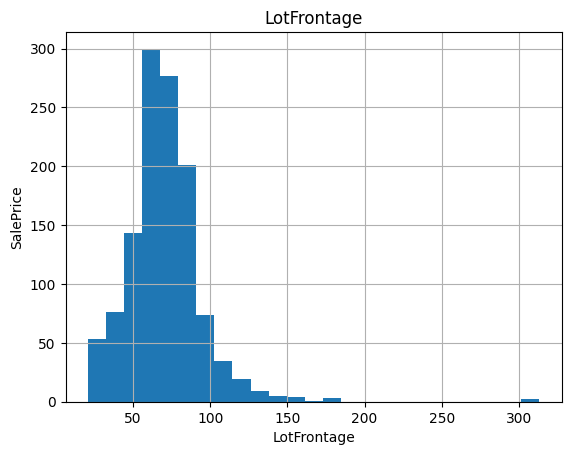

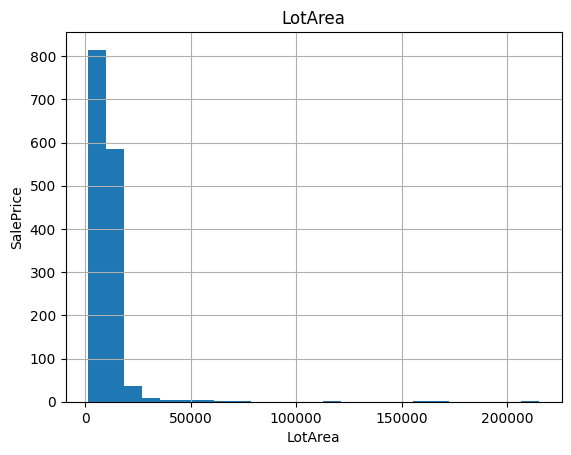

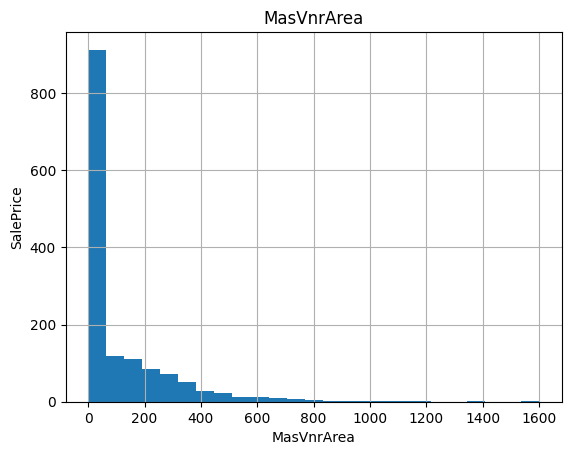

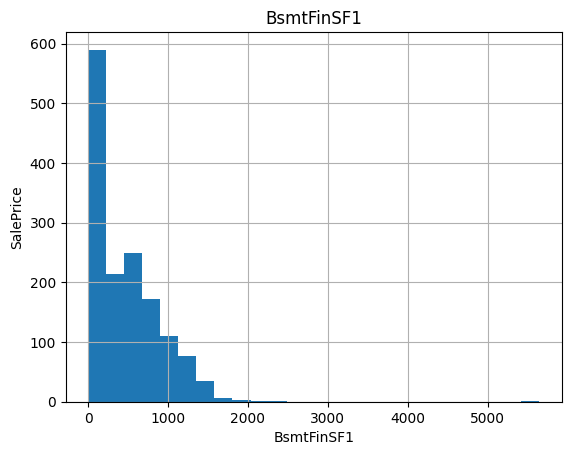

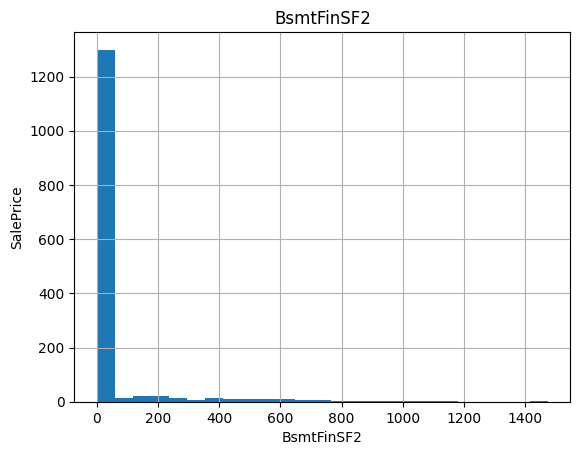

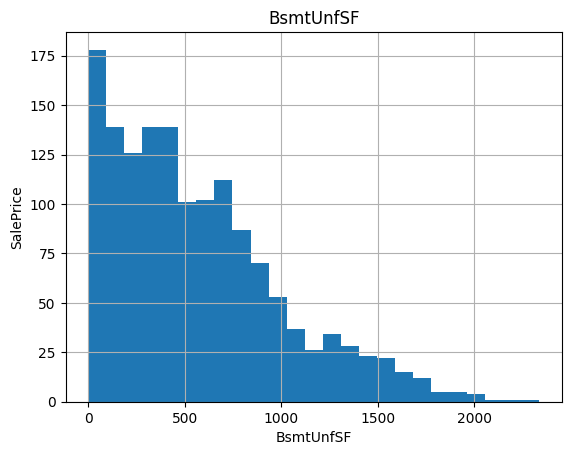

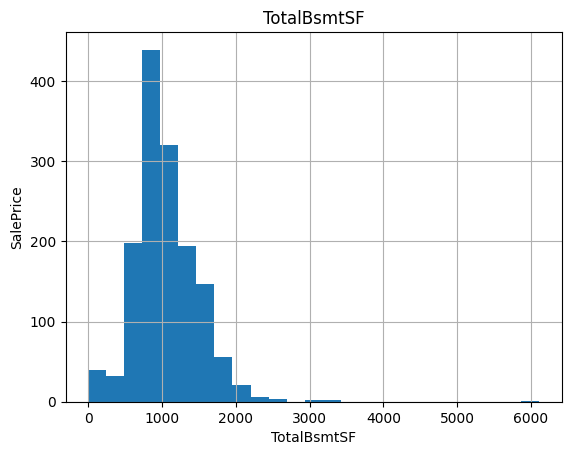

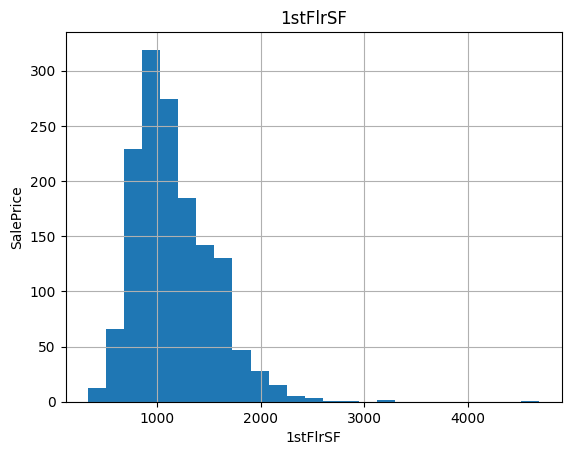

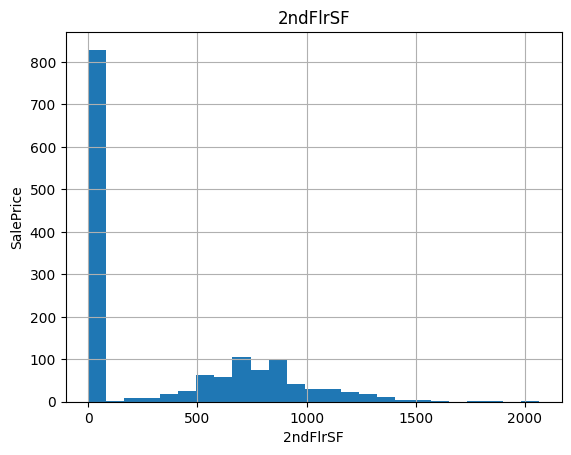

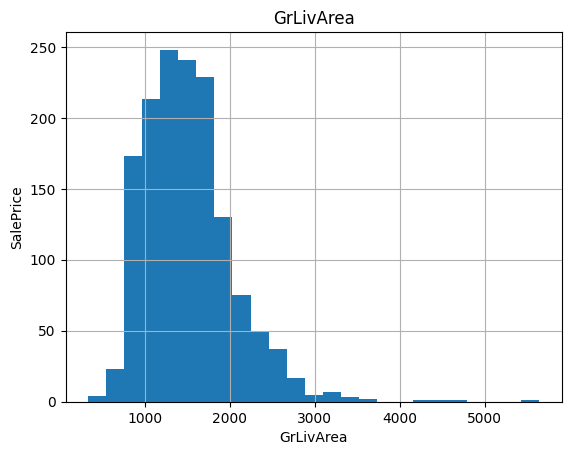

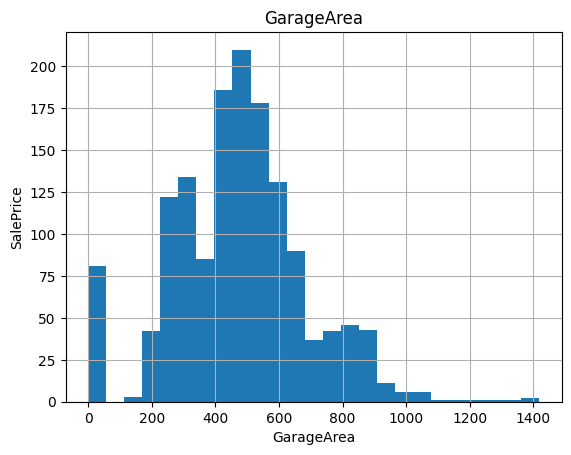

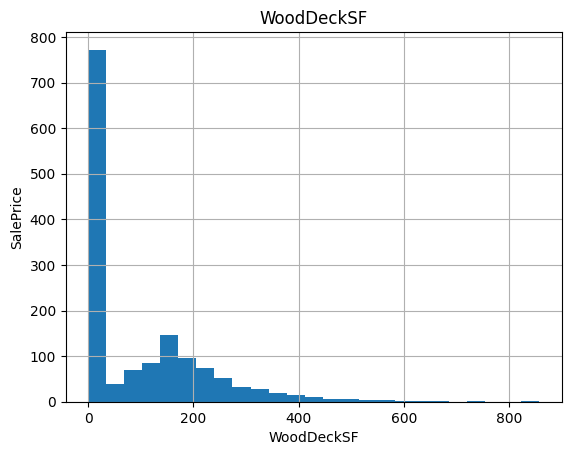

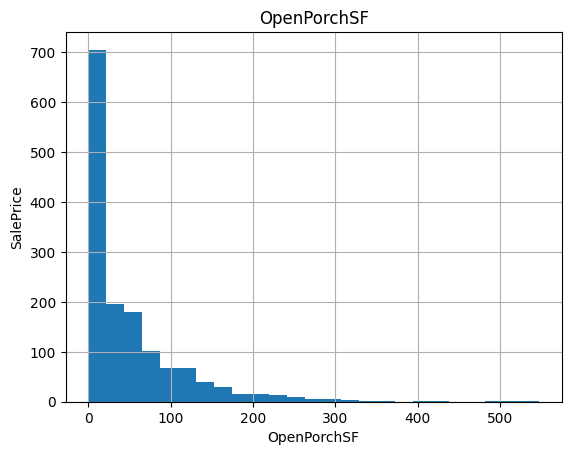

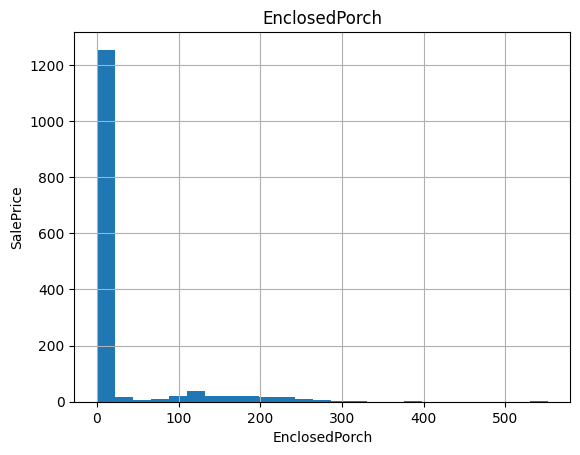

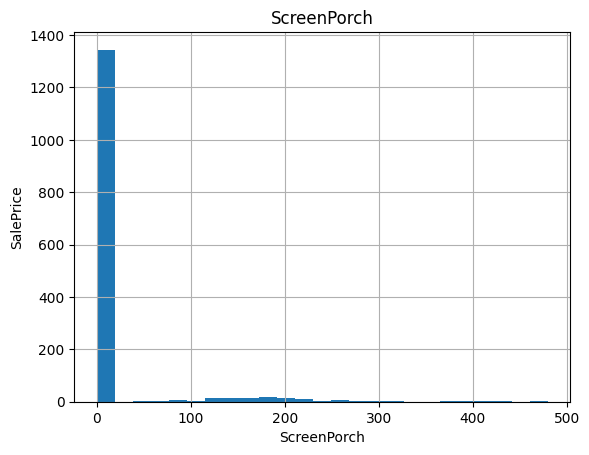

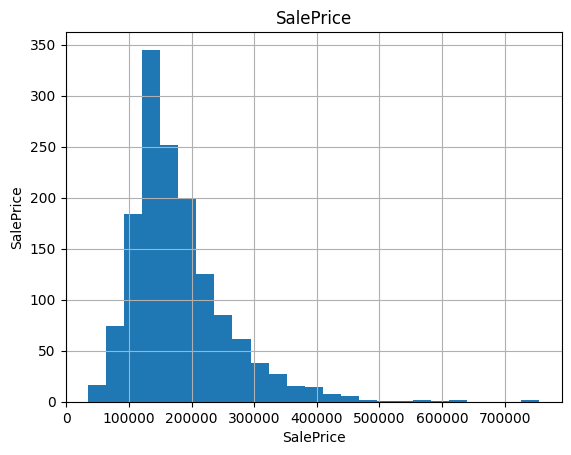

In [91]:
for features in Num_var_cont:   # Non uniform or normal distribution
  df[features].hist(bins=25)
  plt.xlabel(features)
  plt.ylabel('SalePrice')
  plt.title(features)
  plt.show()

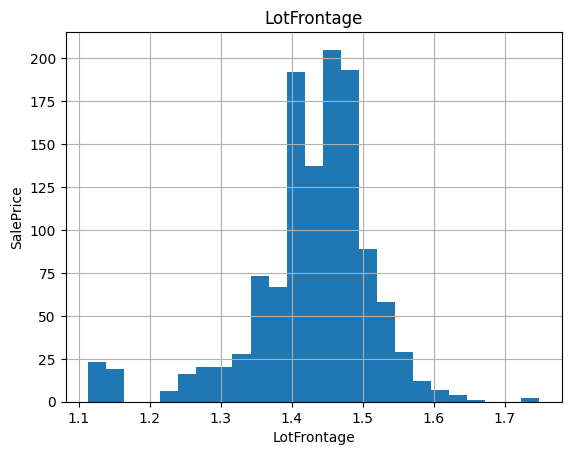

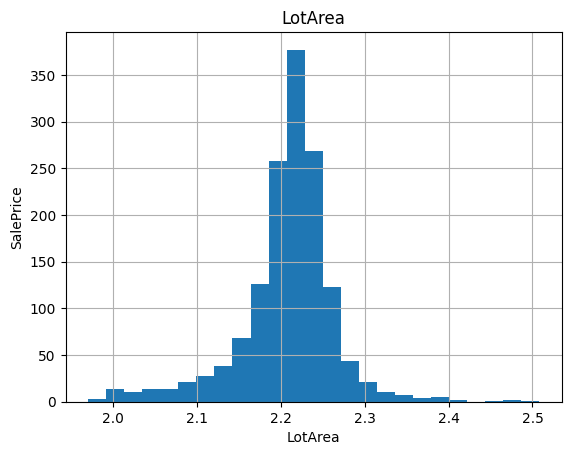

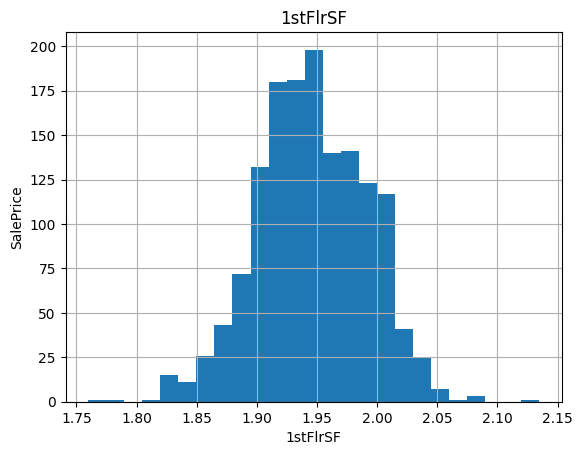

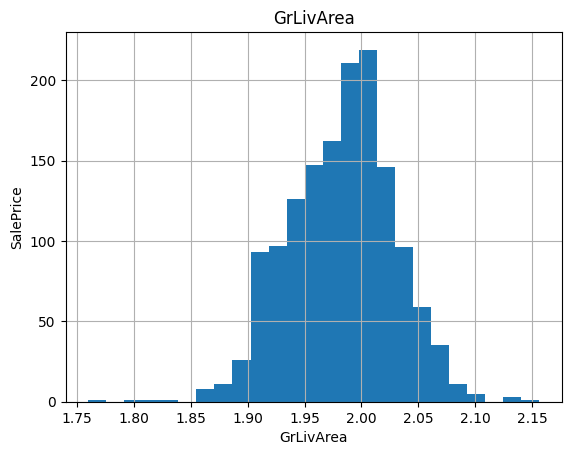

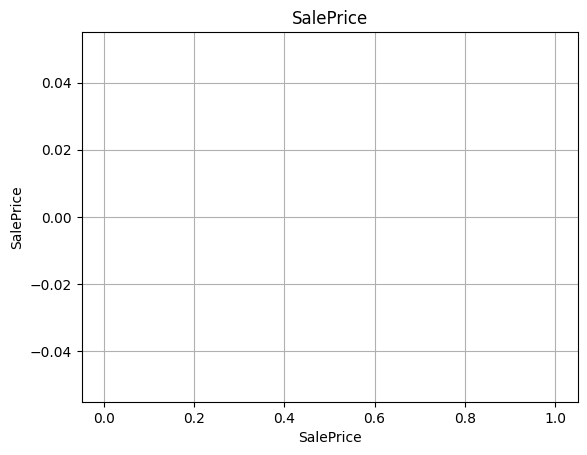

In [99]:
for features in Num_var_cont:
  if 0 in df[features].unique(): # Normal Distribution now
    pass
  else:
    df['SalePrice'] = np.log(df['SalePrice'])
    df[features] = np.log(df[features])
    df[features].hist(bins=25)
    plt.xlabel(features)
    plt.ylabel('SalePrice')
    plt.title(features)
    plt.show()

# Sales Price for different Categorical features


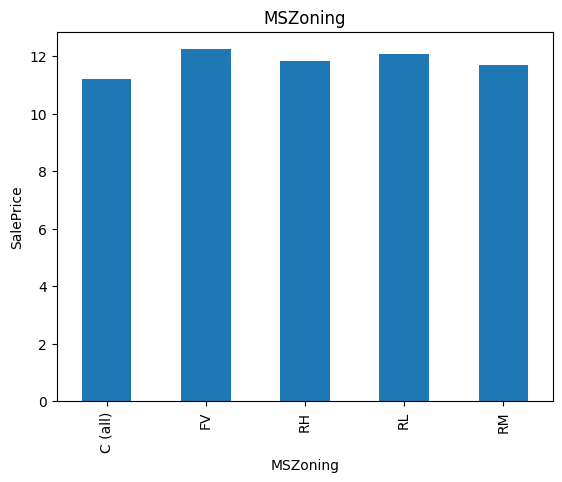

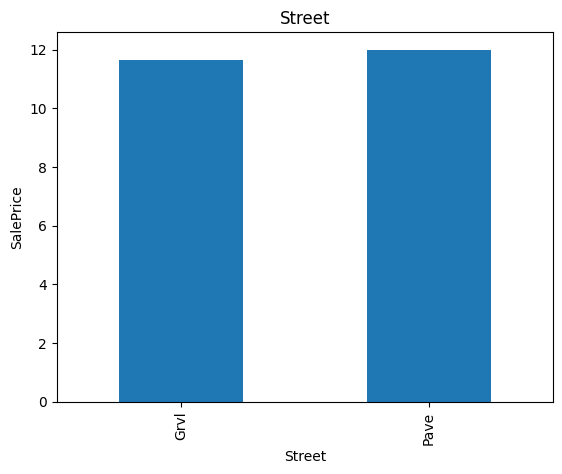

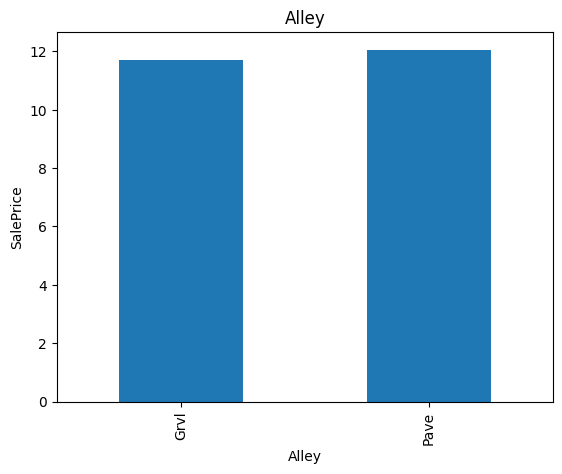

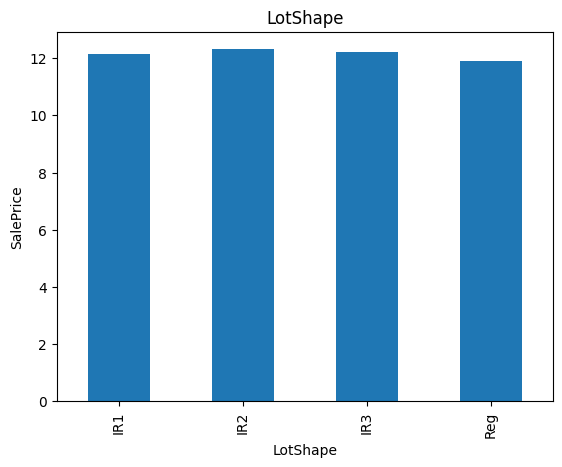

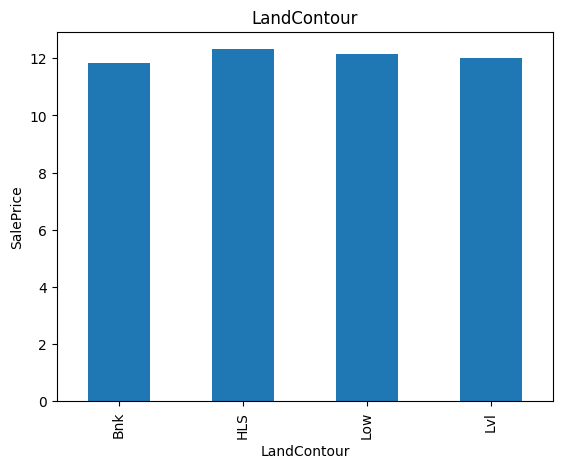

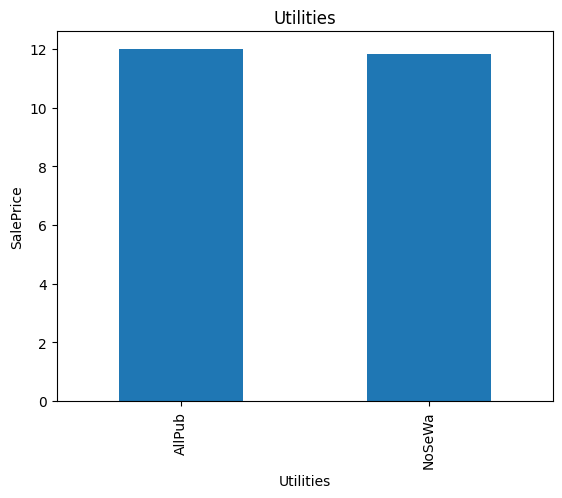

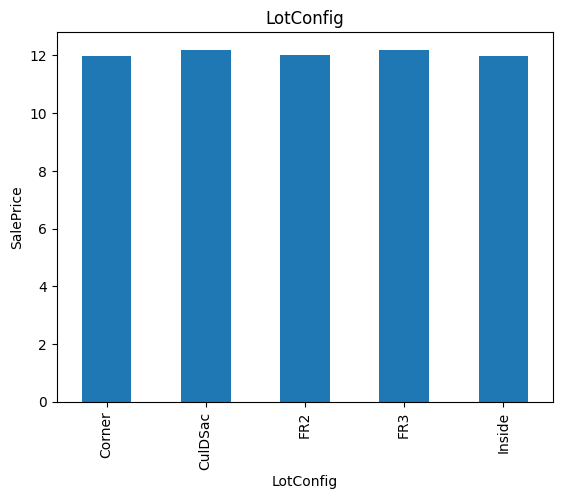

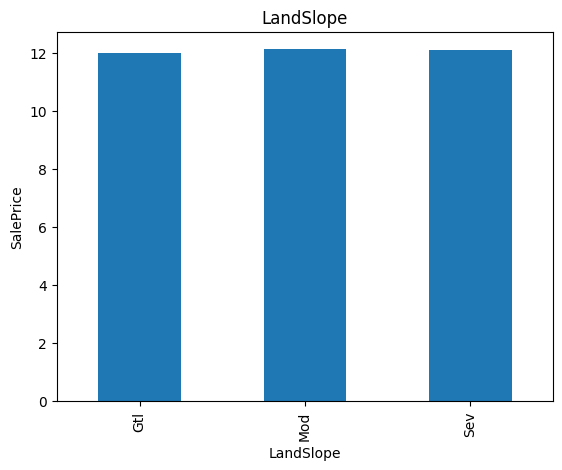

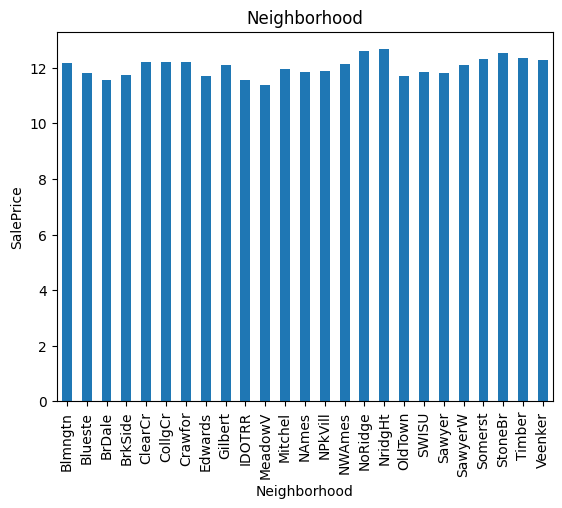

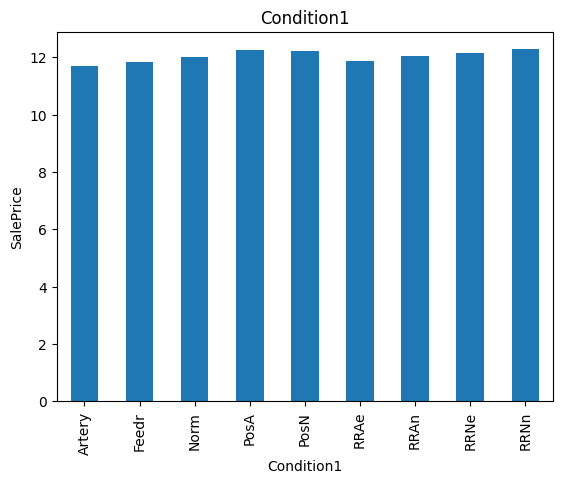

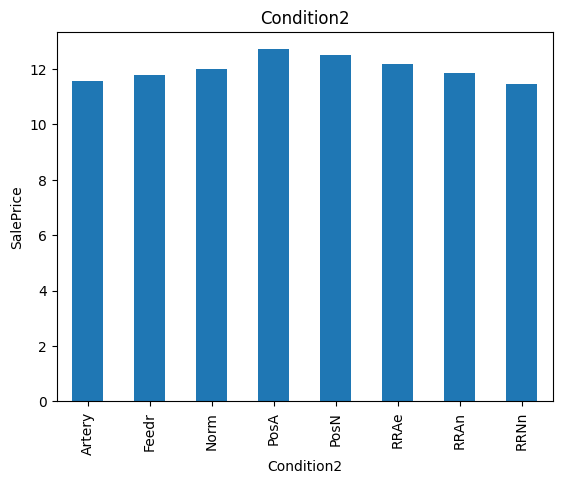

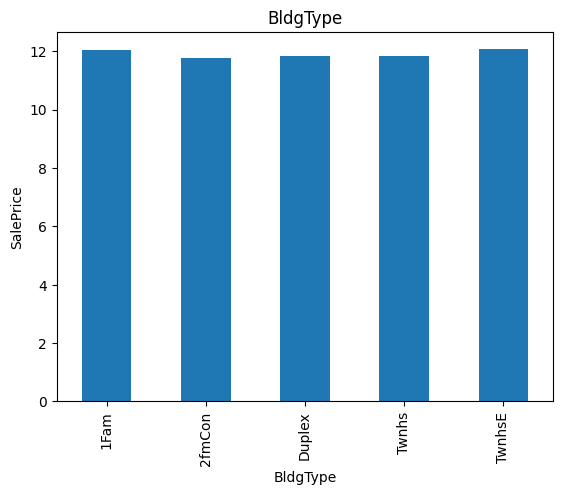

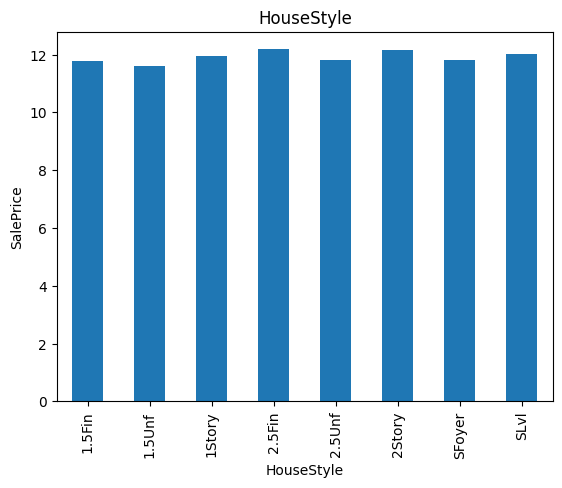

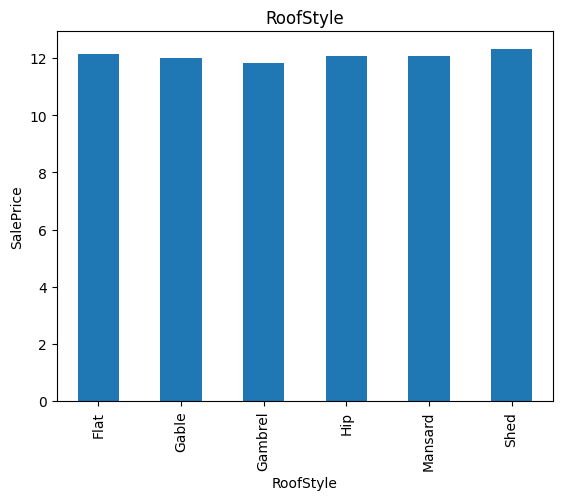

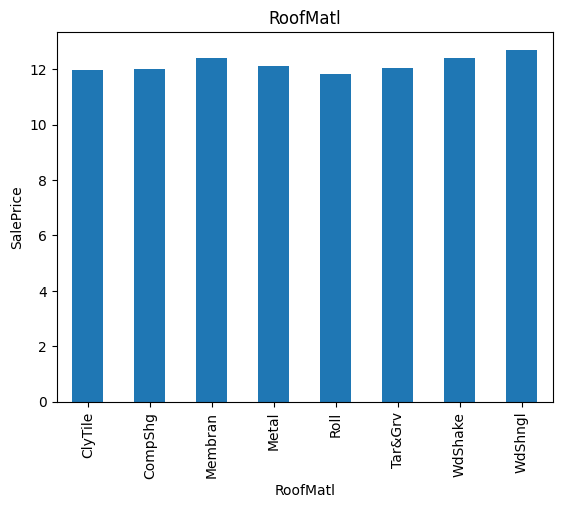

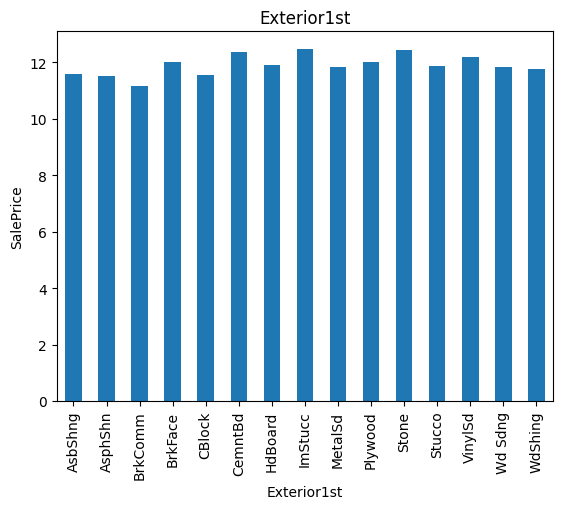

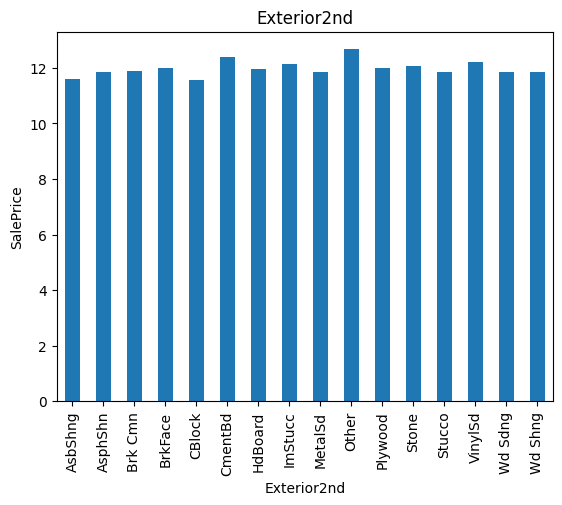

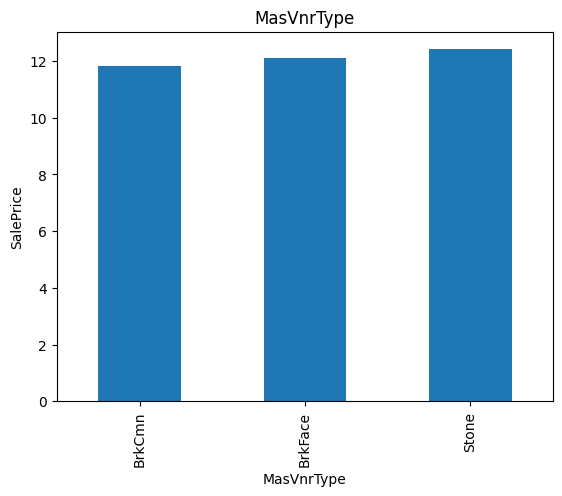

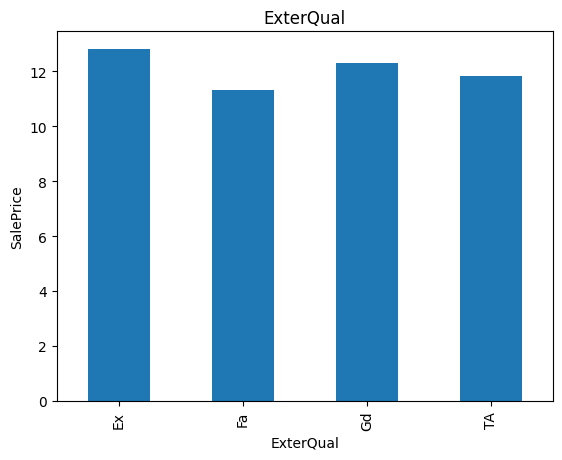

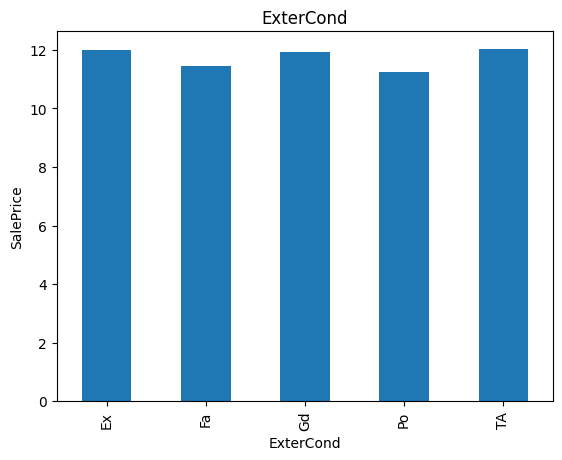

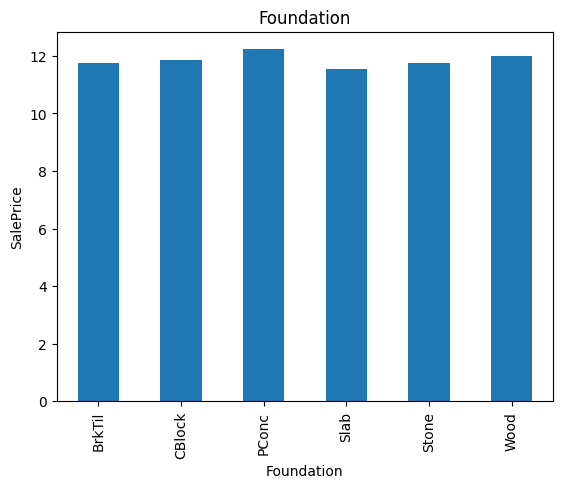

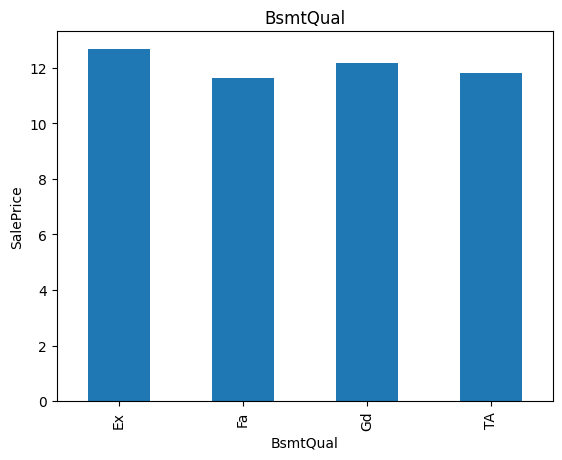

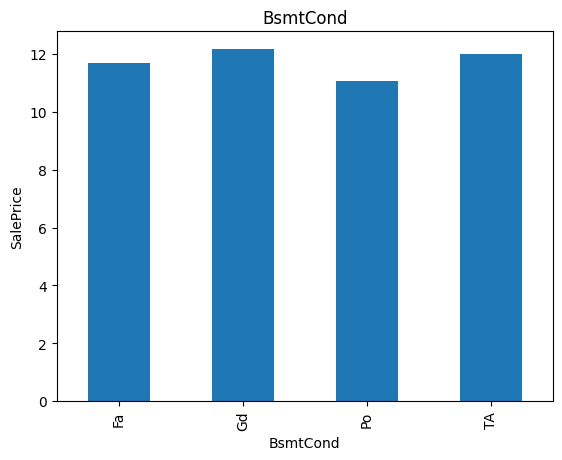

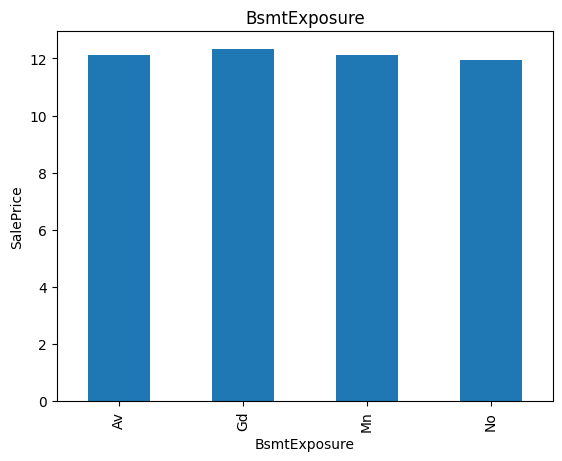

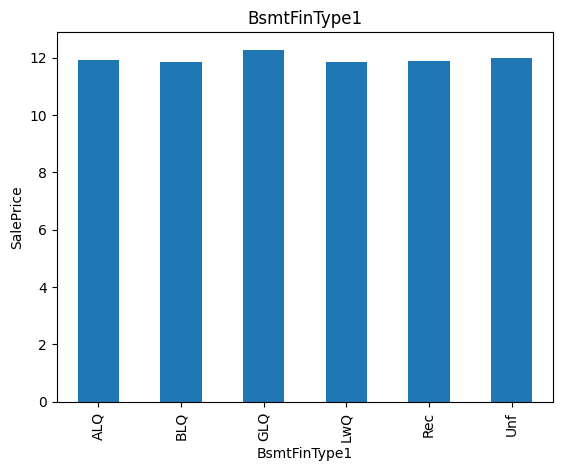

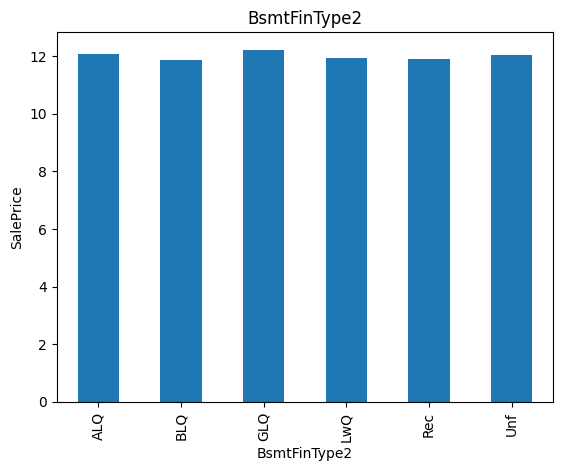

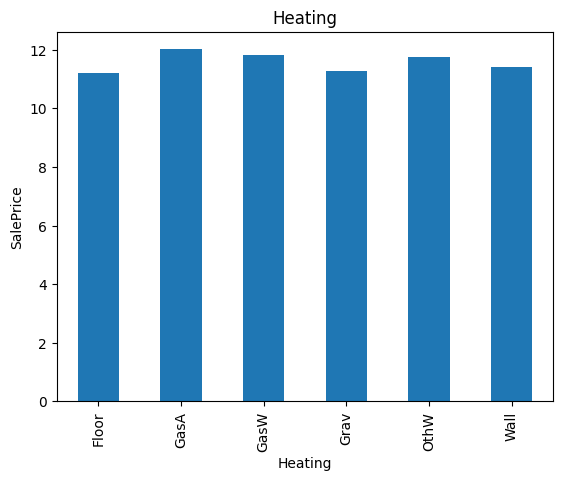

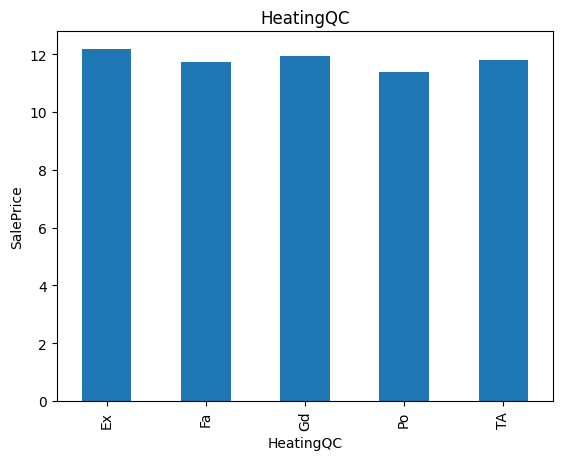

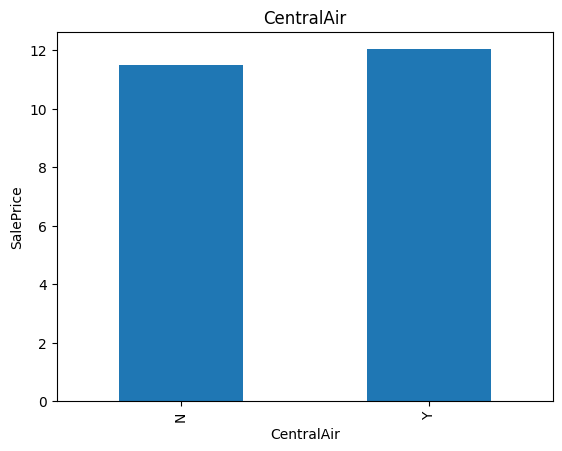

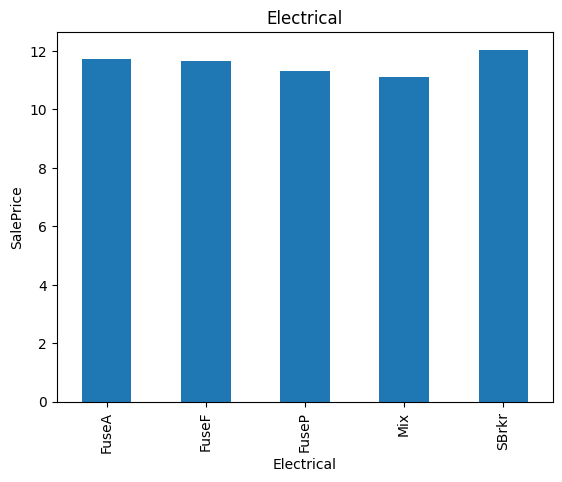

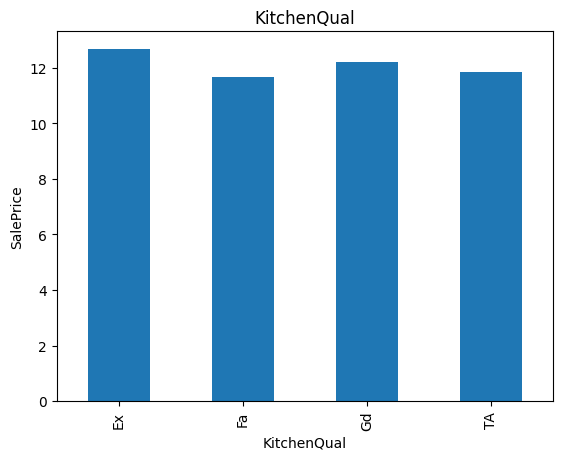

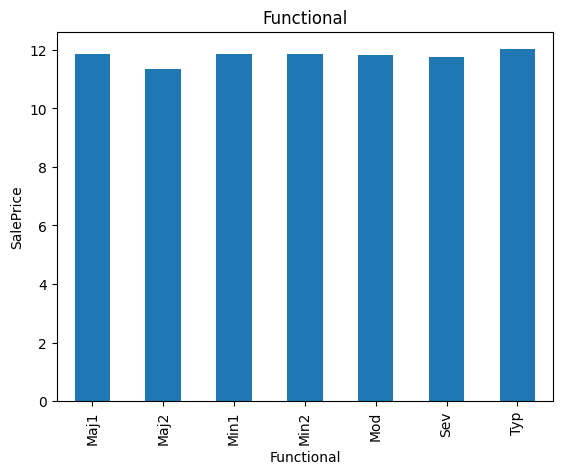

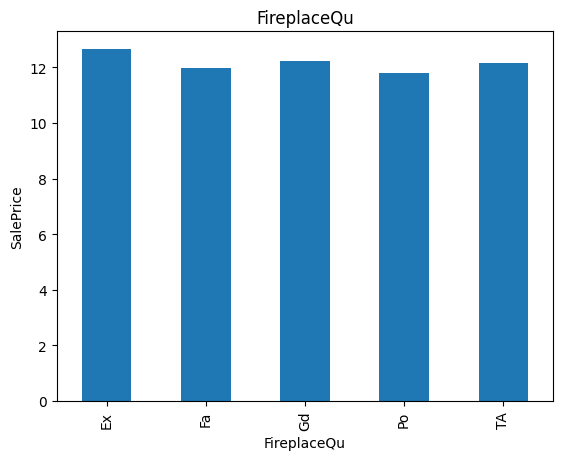

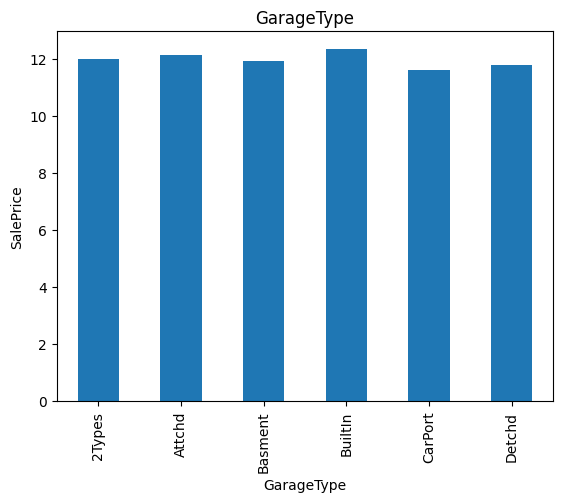

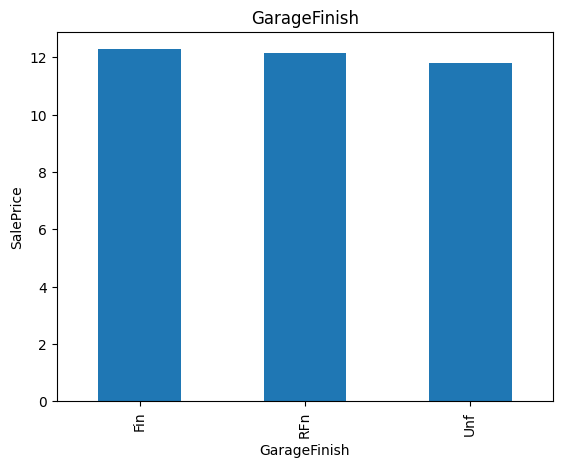

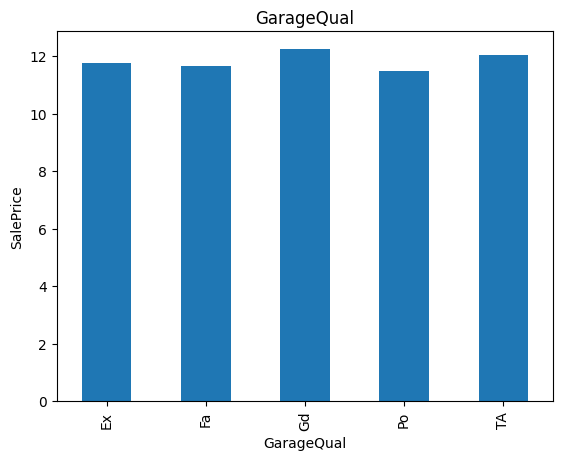

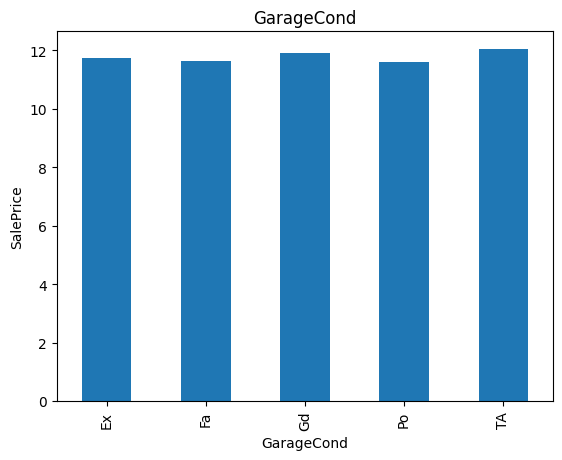

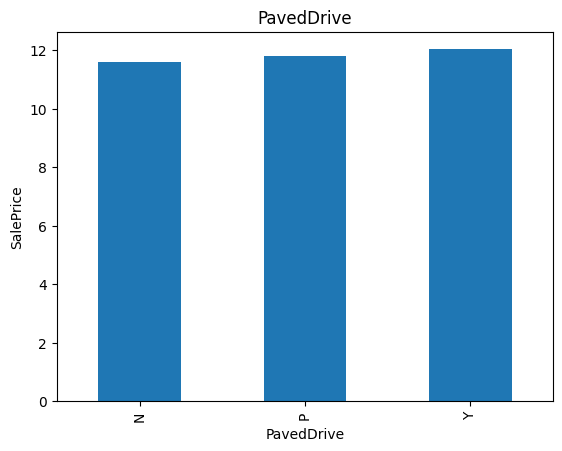

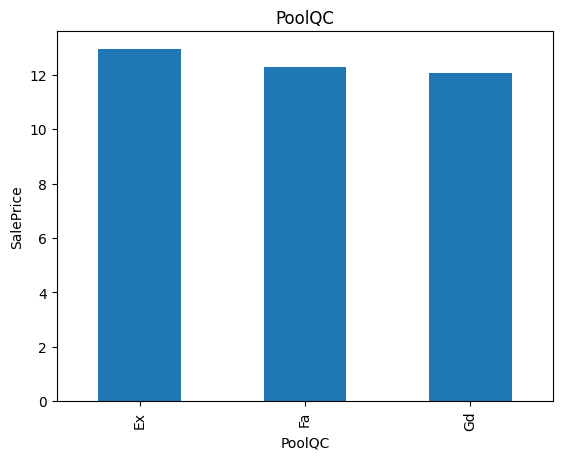

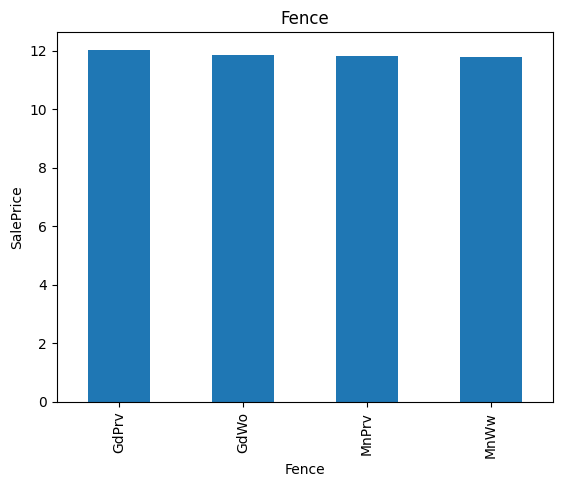

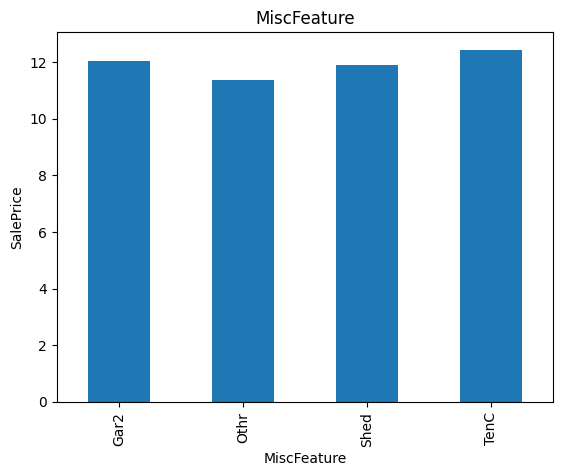

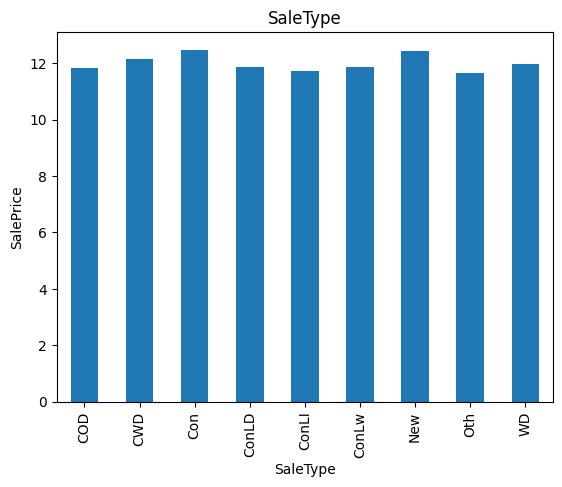

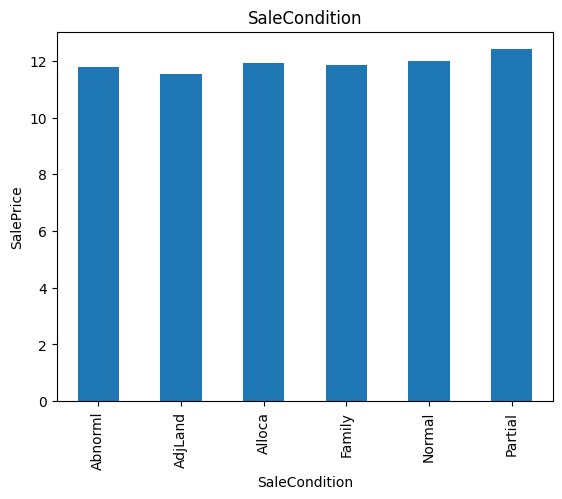

In [107]:
for features in Cat_var:
  df.groupby(features)['SalePrice'].median().plot.bar()
  plt.xlabel(features)
  plt.ylabel('SalePrice')
  plt.title(features)
  plt.show()

# Outliers Detection


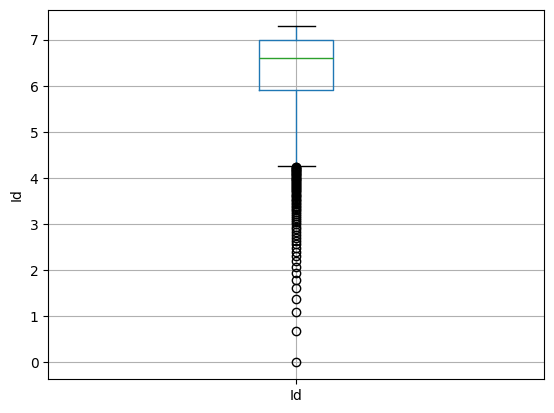

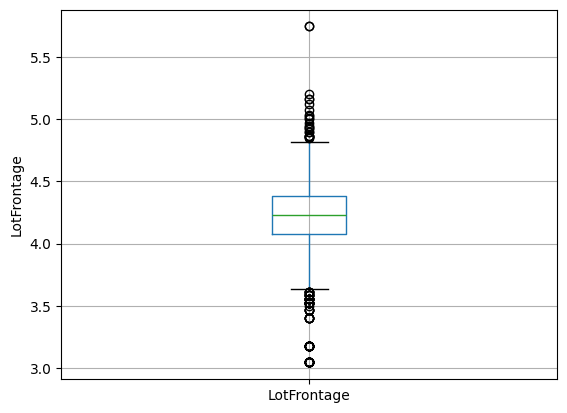

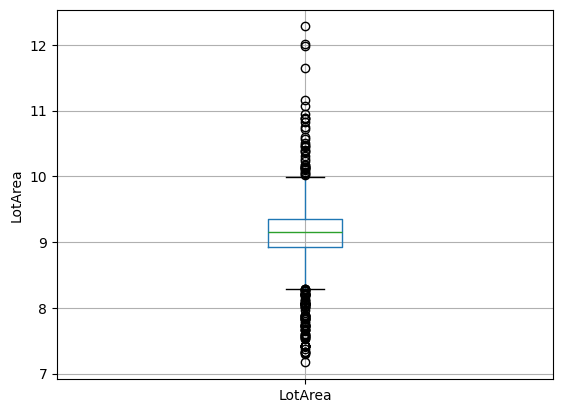

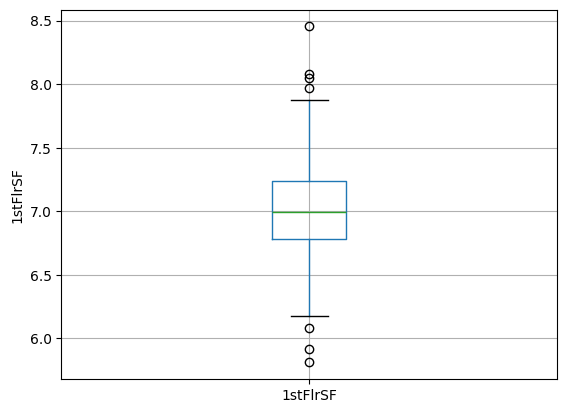

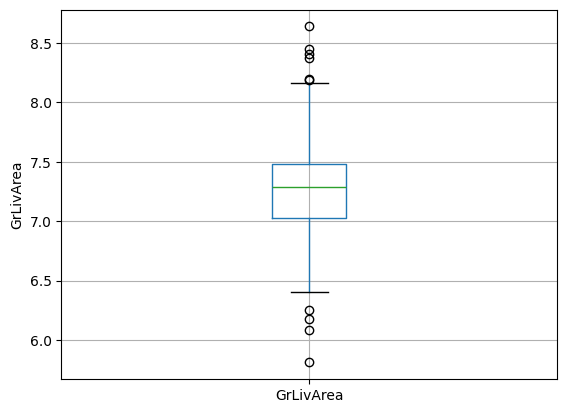

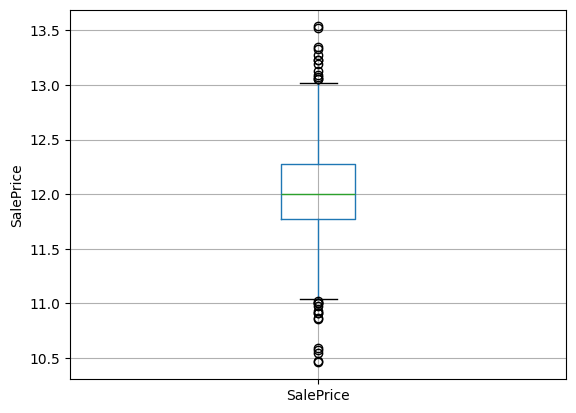

In [106]:
from IPython.utils.text import FullEvalFormatter
for features in Num_var_cont:
  if 0 in df[features].unique():
    pass
  else:
    df[features]= np.log(df[features])
    df.boxplot(column=features)
    plt.ylabel(features)
    plt.show()